# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [2]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [3]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Dao Van Cong"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600031"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [37]:
display_student_header()
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://washer-attitude-wisdom-tigers.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [38]:
display_student_header()
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 5 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 73.4% | Mem: 13.2/16.0GB | Power: 66W | Temp: 65°C
   GPU 1 [T4] 🔴 Util: 82.6% | Mem: 8.6/16.0GB | Power: 64W | Temp: 57°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 62.2% | Mem: 43.4/80.0GB | Power: 200W | Temp: 57°C
   GPU 1 [A100] 🔴 Util: 82.5% | Mem: 46.2/80.0GB | Power: 237W | Temp: 56°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 82.4% | Mem: 17.5/32.0GB | Power: 277W | Temp: 63°C
   GPU 1 [V100] 🟢 Util: 7.0% | Mem: 1.6/32.0GB | Power: 32W | Temp: 32°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 91.1% | Mem: 13.1/16.0GB | Power: 56W | Temp: 77°C
   GPU 1 [T4] 🔴 Util: 67.4% | Mem: 8.8/16.0GB | Power: 54W | Temp: 69°C

🖥️  node-04:
   GPU 0 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C
   GPU 1 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C


In [39]:
display_student_header()
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          10
Busy GPUs:           7
Idle GPUs:           3
Avg Utilization:     54.9%
Memory Used:         153.3 GB
Memory Capacity:     320.0 GB
Total Power Draw:    1025 W
Node Count:          5


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [40]:
display_student_header()
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-04', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-04', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 10/10 | Utilization: 79.7%


In [41]:
display_student_header()
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.5589
   Total Savings:  $2.7078
   Budget Used:    2.6%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [42]:
display_student_header()
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2410     31.1    % low
A100       $3.67       $2.6508     27.8    % high
V100       $2.48       $1.9002     23.4    % high


In [43]:
display_student_header()
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [44]:
display_student_header()
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 2
   Still active: 4

   ⚠️  Preempted:
      - spot-t4-002 (ran for 5s, 120s warning)
      - opt-spot-0 (ran for 1455s, 60s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0866
   On-demand equiv:  $0.2887
   Total saved:      $0.2021 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [45]:
display_student_header()
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [46]:
display_student_header()
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 79.7% > threshold 70.0%
   Current utilization: 79.7%
   Nodes: 5 → 6

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 66.4% | Nodes: 6→6
   Cycle 2: no_action    | Util: 66.4% | Nodes: 6→6
   Cycle 3: no_action    | Util: 66.4% | Nodes: 6→6
   Cycle 4: no_action    | Util: 66.4% | Nodes: 6→6
   Cycle 5: no_action    | Util: 66.4% | Nodes: 6→6


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [49]:
display_student_header()
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 2: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 3: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 4: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 5: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%


In [50]:
display_student_header()
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.6%
   Total Idle Cost:        $0.019440
   Total Cost:             $0.419440
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [51]:
display_student_header()
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [52]:
display_student_header()
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 12 GPUs across 6 nodes
   Utilization: 66.4% | Busy: 10 | Idle: 2

💰 BILLING: $2.5589 / $100.00 budget
   Alert: OK | Savings: $2.7078

🎯 SPOT: Saved $0.6980 (70.0%)

🗑️  WASTE: 4.6% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

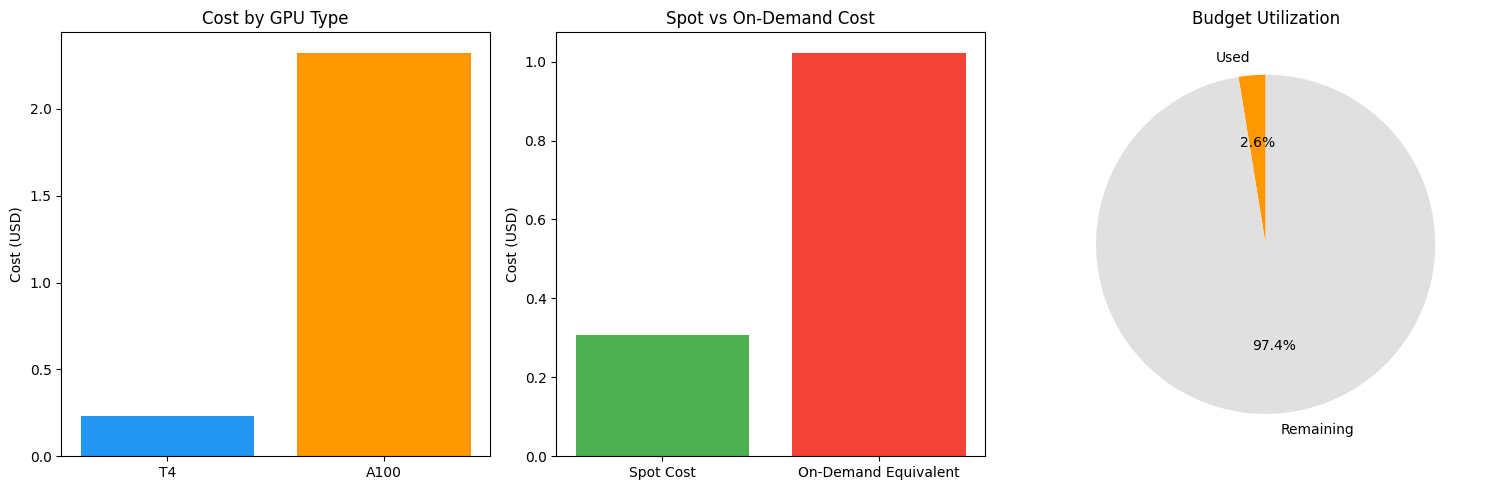

📊 Chart saved as finops_cost_breakdown.png


In [53]:
display_student_header()
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


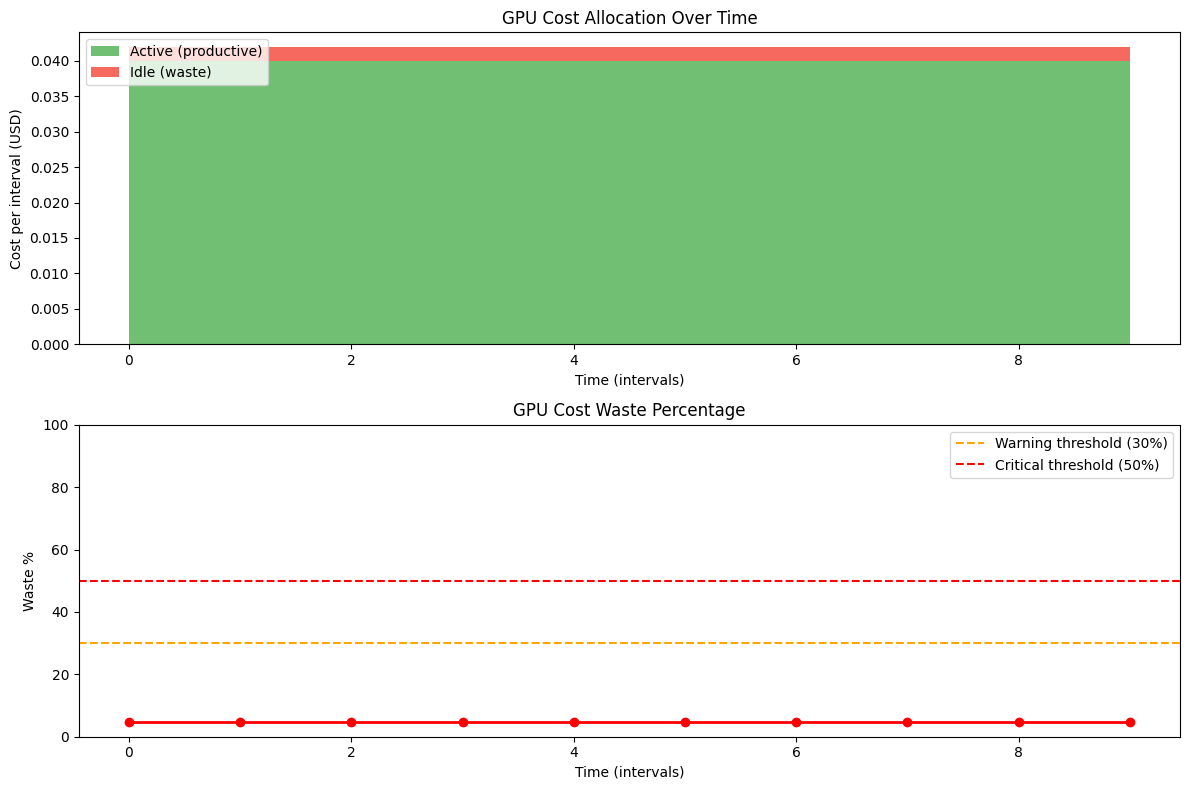

In [54]:
display_student_header()
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [55]:
display_student_header()
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 12 | Util: 66.4% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 79.1% | Busy: 12/12

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 79.1% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.043889
   Waste: 4.4%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.5390 (70.0%)

7️⃣  Final billing:
   Total spend: $2.7280
   Total saved: $2.8302
   Budget: 2.7% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [56]:
display_student_header()
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [57]:
display_student_header()
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=1684/16106 MB
   Power: 30.4W
   Temp: 75C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 1684.209664
   mem_util_pct: 0.0
   power_watts: 30.401
   temp_c: 75.0

   Method: pynvml

Ready for training.


In [58]:
display_student_header()
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [59]:
display_student_header()
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.9713 | Acc: 29.9% | Time: 42.0s | Samples: 40
   Epoch 2/3 | Loss: 1.4073 | Acc: 48.3% | Time: 41.5s | Samples: 40
   Epoch 3/3 | Loss: 1.0988 | Acc: 60.6% | Time: 41.7s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      125.3s
   Peak memory:     0.97 GB
   Avg GPU util:    95.4%
   Avg power:       67.5W
   Avg temperature: 77.4C
   Max GPU util:    99.0%
   Estimated cost:  $0.012180


In [60]:
display_student_header()
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/607681367.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/607681367.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9417 | Acc: 28.9% | Time: 19.0s | Samples: 40
   Epoch 2/3 | Loss: 1.4337 | Acc: 47.0% | Time: 19.2s | Samples: 40
   Epoch 3/3 | Loss: 1.1627 | Acc: 58.1% | Time: 19.0s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      57.2s
   Peak memory:     0.60 GB
   Avg GPU util:    90.7%
   Avg power:       65.6W
   Avg temperature: 78.4C
   Max GPU util:    93.0%
   Estimated cost:  $0.005561


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                125.3           57.2            2.19x faster
Peak Memory (GB)          0.97            0.60            0.36 GB saved
Cost (USD)                $0.012180       $0.005561       $0.006619 saved
Cost Saving %             ---             ---             54.3%
Avg GPU Util %            95.4            90.7           
Avg Power (W)             67.5            65.6           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.84 -> SAVE $4.56
   1 week training: FP32=$58.80 vs AMP=$26.85 -> SAVE $31.95
   1 month training: FP32=$252.00 vs AMP=$115.05 -> SAVE $136.95


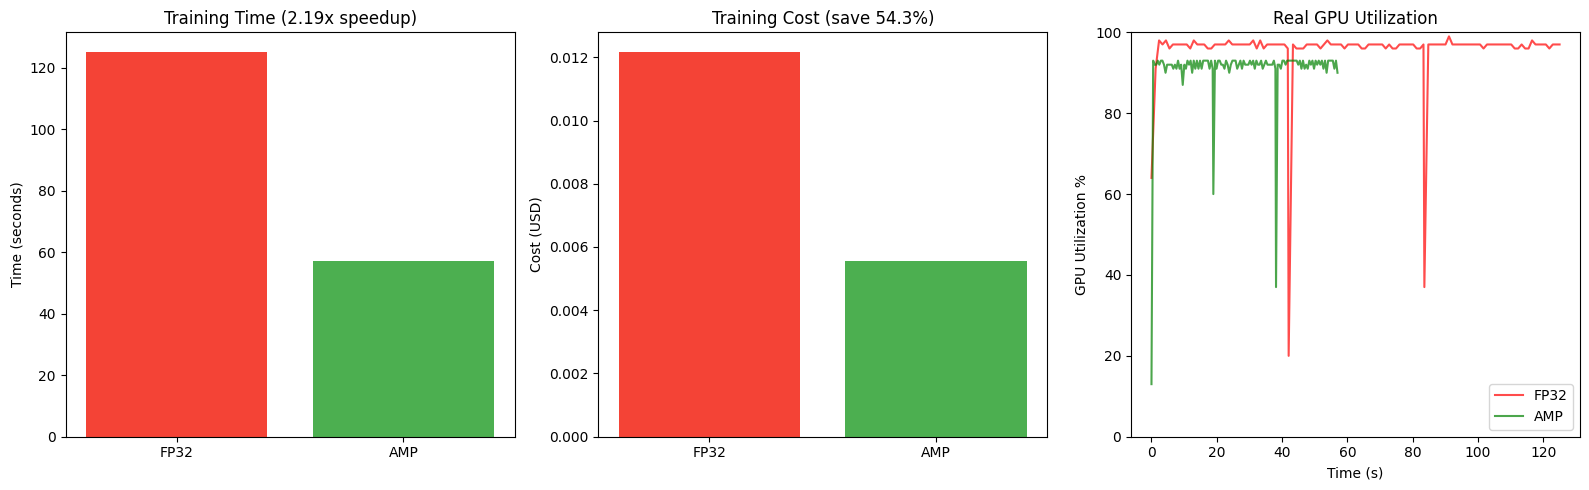

In [61]:
display_student_header()
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
display_student_header()
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012200 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.003900

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.027300
   Total Savings:   $0.007800
   Workloads:       4

   Cost snapshot taken: waste=20.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.7280
   Total Savings:        $2.8302
   Budget Utilization:   2.7%
   Alert:                OK


Real GPU Telemetry During Training


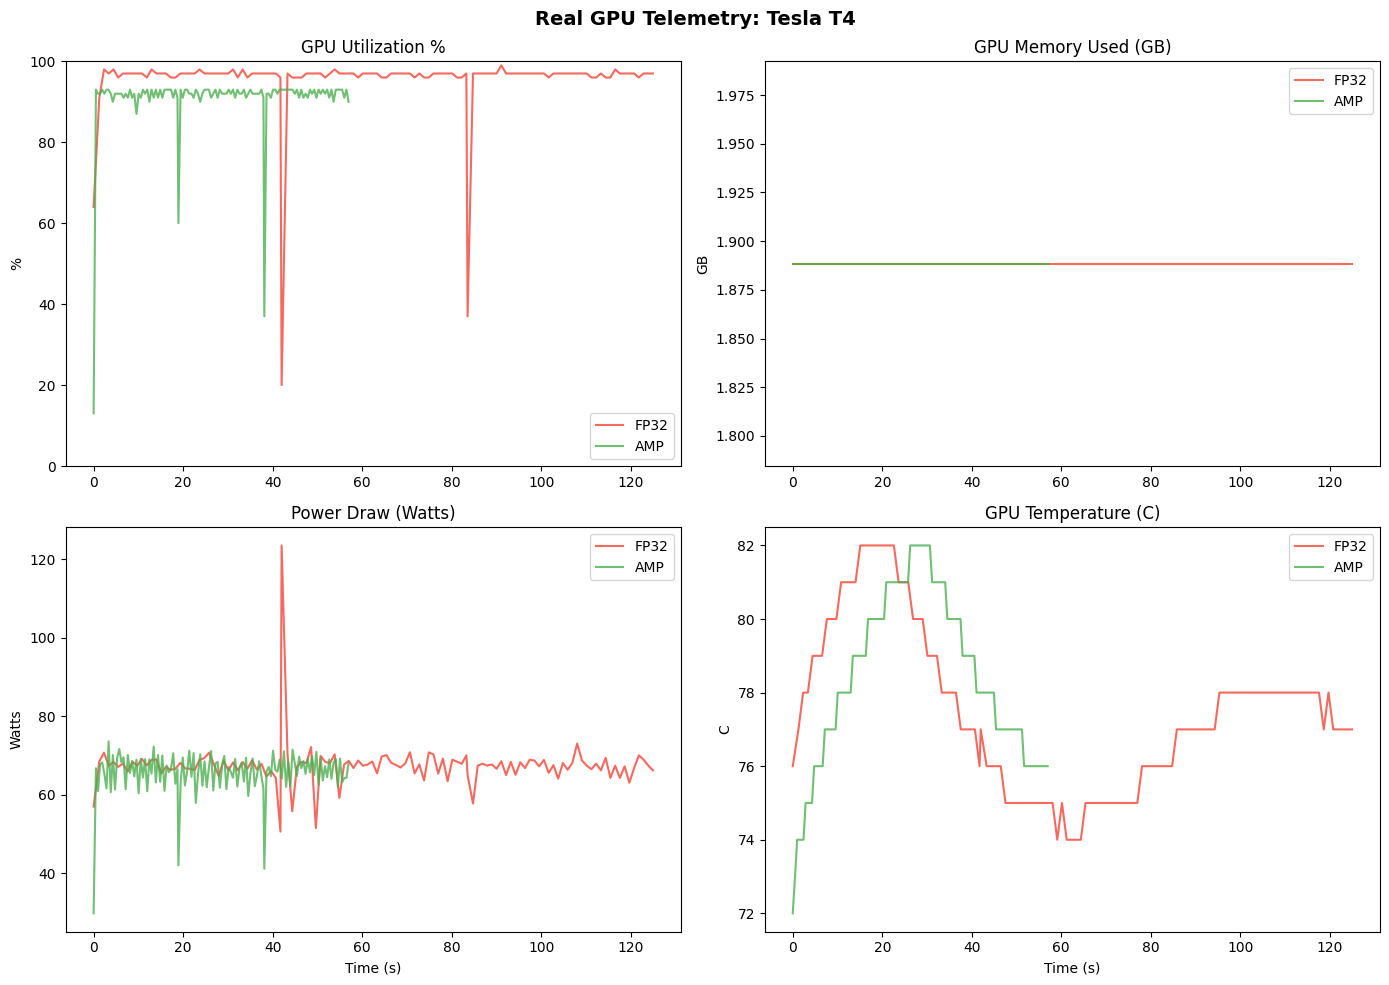

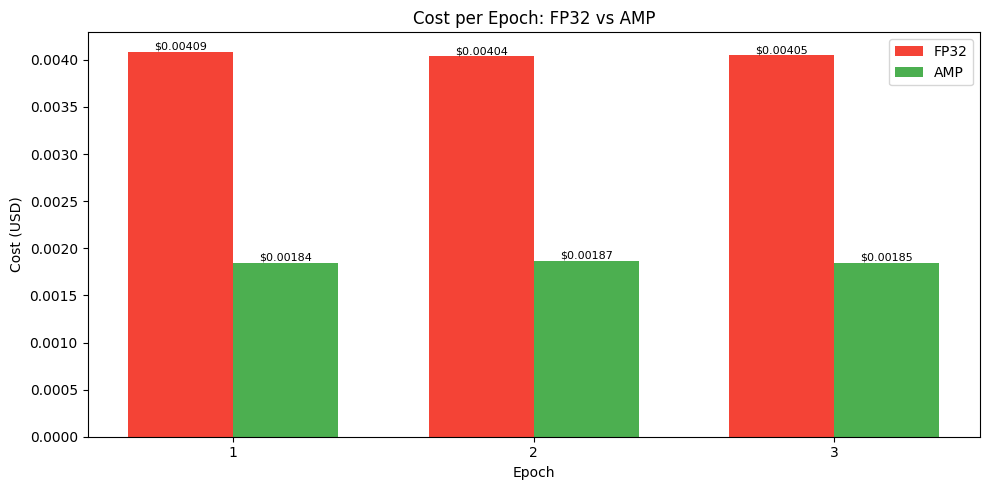


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [68]:
display_student_header()
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

🖥️  GPU Type      : T4
💰 Price/Hour    : $0.35
⏱️  Base Time (1 GPU): 2.0 hrs

GPUs   Speedup    Time(h)    Cost($)    Efficiency   Cost/Perf 
------------------------------------------------------------
8      5.6        0.36       1.0        70.0         0.1786     ⭐

✅ Optimal GPU count: 8 GPUs
   Cost/Perf ratio : $0.1786
   Efficiency      : 70.0%


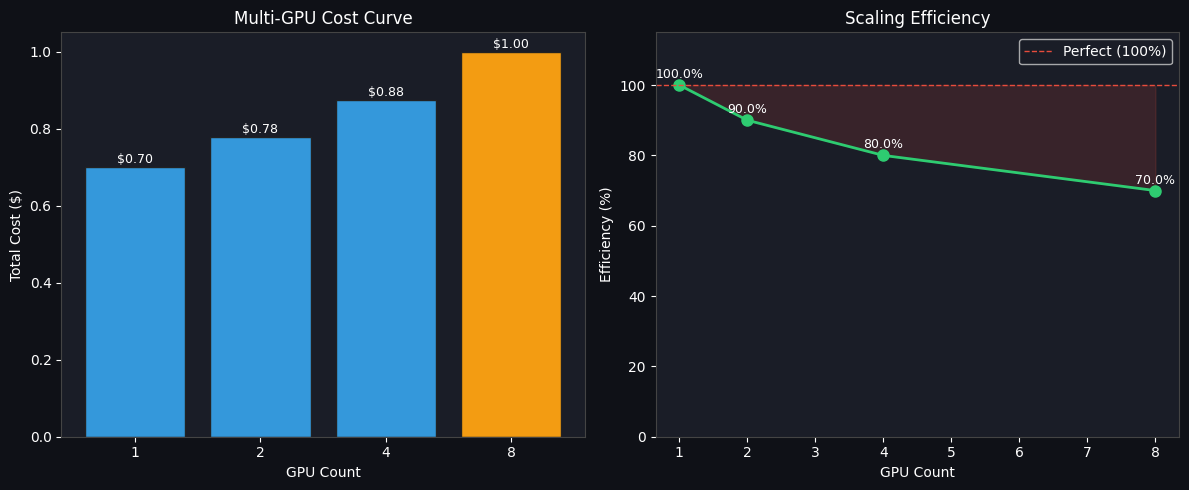

✅ Saved: multi_gpu_scaling.png


In [79]:
display_student_header()
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# TODO: Implement function to analyze costs for different GPU counts
# Hint: Consider scaling efficiency - more GPUs doesn't always mean linear speedup

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    # Base URL Cloudflare Tunnel
    BASE_URL = "https://washer-attitude-wisdom-tigers.trycloudflare.com"
    # Get base price from API
    r = requests.get( f"{BASE_URL}/", timeout=10 )
    
    pricing = r.json()
    
    # Find price for gpu_type (fallback to T4 price if not found)
    base_price = None
    for item in pricing.get("pricing", []):
        if gpu_type.upper() in item.get("gpu_type", "").upper():
            base_price = item["price_per_hour"]
            break
    if base_price is None:
        base_price = 0.35  # default T4 price
    
    # Realistic sub-linear scaling nếu không truyền vào
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0,   # 1 GPU  = 1.0x speedup (baseline)
            2: 1.8,   # 2 GPUs = 1.8x (90% efficiency)
            4: 3.2,   # 4 GPUs = 3.2x (80% efficiency)
            8: 5.6,   # 8 GPUs = 5.6x (70% efficiency)
        }
    
    results = []
    for count in gpu_counts:
        factor = scaling_factors.get(count, count * 0.65)  # fallback estimate
        time_hours = base_time_hours / factor
        total_cost = time_hours * base_price * count
        efficiency = factor / count  # scaling efficiency (1.0 = perfect linear)
        cost_per_perf = total_cost / factor  # cost per unit of performance
        
        results.append({
            "gpu_count": count,
            "scaling_factor": round(factor, 2),
            "time_hours": round(time_hours, 2),
            "total_cost_usd": round(total_cost, 4),
            "efficiency_pct": round(efficiency * 100, 1),
            "cost_per_perf": round(cost_per_perf, 4),
        })
    
    # Tìm optimal (cost_per_perf thấp nhất)
    optimal = min(results, key=lambda x: x["cost_per_perf"])
    
    return {
        "gpu_type": gpu_type,
        "base_price_per_hour": base_price,
        "base_time_hours": base_time_hours,
        "configurations": results,
        "optimal_gpu_count": optimal["gpu_count"],
        "optimal_config": optimal,
    }

# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

# Gọi function
analysis = analyze_multi_gpu_cost(base_training_time, "T4", test_gpu_counts)

# Hiển thị kết quả
print(f"\n🖥️  GPU Type      : {analysis['gpu_type']}")
print(f"💰 Price/Hour    : ${analysis['base_price_per_hour']:.2f}")
print(f"⏱️  Base Time (1 GPU): {analysis['base_time_hours']} hrs\n")

print(f"{'GPUs':<6} {'Speedup':<10} {'Time(h)':<10} {'Cost($)':<10} {'Efficiency':<12} {'Cost/Perf':<10}")
print("-" * 60)
for cfg in analysis["configurations"]:
    marker = " ⭐" if cfg["gpu_count"] == analysis["optimal_gpu_count"] else ""
print(f"{cfg['gpu_count']:<6} {cfg['scaling_factor']:<10} {cfg['time_hours']:<10} "
          f"{cfg['total_cost_usd']:<10} {cfg['efficiency_pct']:<12} {cfg['cost_per_perf']:<10}{marker}")

print(f"\n✅ Optimal GPU count: {analysis['optimal_gpu_count']} GPUs")
print(f"   Cost/Perf ratio : ${analysis['optimal_config']['cost_per_perf']}")
print(f"   Efficiency      : {analysis['optimal_config']['efficiency_pct']}%")

# Save multi_gpu_scaling.png
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig1.patch.set_facecolor("#0f1117")
for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

cfgs = analysis["configurations"]
gpu_counts   = [c["gpu_count"]      for c in cfgs]
costs        = [c["total_cost_usd"] for c in cfgs]
efficiencies = [c["efficiency_pct"] for c in cfgs]
optimal      = analysis["optimal_gpu_count"]

colors = ["#f39c12" if g == optimal else "#3498db" for g in gpu_counts]
bars = ax1.bar([str(g) for g in gpu_counts], costs, color=colors, edgecolor="#222")
ax1.set_title("Multi-GPU Cost Curve", color="white")
ax1.set_xlabel("GPU Count")
ax1.set_ylabel("Total Cost ($)")
for bar, cost in zip(bars, costs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"${cost:.2f}", ha="center", color="white", fontsize=9)

ax2.plot(gpu_counts, efficiencies, "o-", color="#2ecc71", linewidth=2, markersize=8)
ax2.axhline(100, color="#e74c3c", linestyle="--", linewidth=1, label="Perfect (100%)")
ax2.fill_between(gpu_counts, efficiencies, 100, alpha=0.15, color="#e74c3c")
ax2.set_title("Scaling Efficiency", color="white")
ax2.set_xlabel("GPU Count")
ax2.set_ylabel("Efficiency (%)")
ax2.set_ylim(0, 115)
for x, y in zip(gpu_counts, efficiencies):
    ax2.text(x, y + 2, f"{y}%", ha="center", color="white", fontsize=9)
ax2.legend(facecolor="#1a1d27", labelcolor="white")

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight", facecolor=fig1.get_facecolor())
plt.show()
print("✅ Saved: multi_gpu_scaling.png")

# # TODO: Call the function and display results
# # Hint: Create a table showing GPU count, time, cost, cost-performance ratio

# print("\n📊 TODO: Implement analyze_multi_gpu_cost function")
# print("   Expected output: Table comparing 1, 2, 4, 8 GPU configurations")
# print("   Show: Time reduction, Total cost, Cost per unit performance")
# print("   Identify: Optimal GPU count for cost efficiency")

EXERCISE 8.5.2: Project Cost Forecasting

Phase                     GPU    Count  Hours   $/hr    Cost($)    Best       Worst      Uncert
-----------------------------------------------------------------------------------------------
Data Preparation          T4     1      40      0.35    14.0       9.88       18.12      15.0%
Model Training            A100   4      120     3.5     1680.0     856.8      2503.2     25.0%
Hyperparameter Tuning     A100   8      60      3.5     1680.0     692.16     2667.84    30.0%
Model Evaluation          T4     2      20      0.35    14.0       11.26      16.74      10.0%

💰 Total Base Cost       : $3,388.00
🛡️  Contingency (20%)    : $677.60
📦 Total with Contingency: $4,065.60

📊 95% Confidence Interval:
   🟢 Best Case  : $2,102.11
   🟡 Expected   : $3,388.00
   🔴 Worst Case : $4,673.89


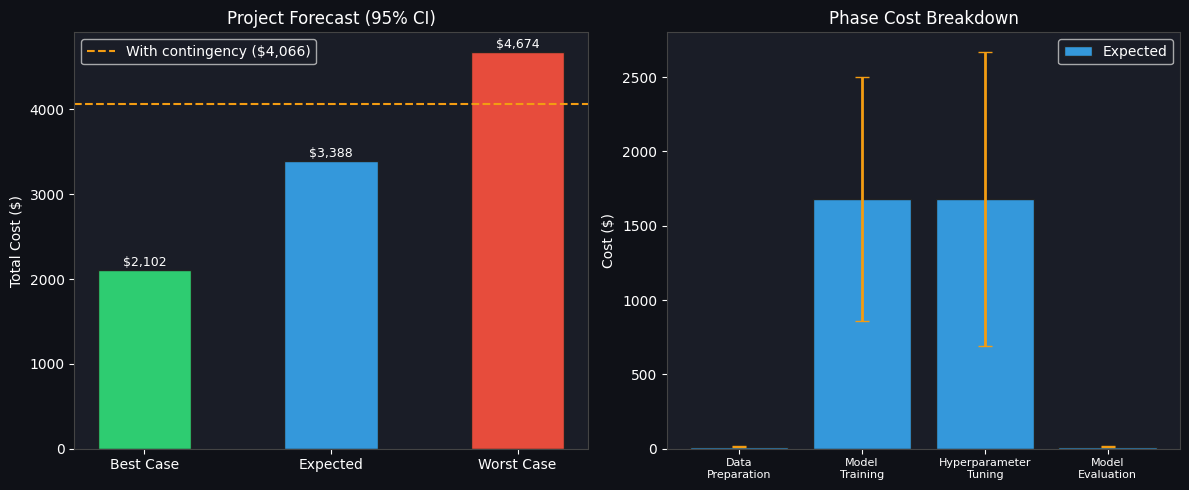

✅ Saved: project_forecast.png


In [80]:
# Cell 28: Project Cost Forecasting
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals.
    """
    # Base URL Cloudflare Tunnel
    BASE_URL = "https://washer-attitude-wisdom-tigers.trycloudflare.com"
    # Get base price from API
    r = requests.get( f"{BASE_URL}/", timeout=10 )
    pricing_data = r.json()

    # Build price lookup dict
    price_lookup = {}
    for item in pricing_data.get("pricing", []):
        gpu_type = item.get("gpu_type", "").upper()
        price_lookup[gpu_type] = item["price_per_hour"]

    # Fallback prices nếu API không có
    fallback_prices = {"T4": 0.35, "A100": 3.50, "V100": 2.48, "P100": 1.46}

    phase_results = []
    total_base = 0
    total_variance = 0

    for phase in phases:
        gpu_type = phase["gpu_type"].upper()
        price = price_lookup.get(gpu_type) or fallback_prices.get(gpu_type, 1.0)

        base_cost = phase["duration_hours"] * price * phase["gpu_count"]
        uncertainty = phase["uncertainty_pct"]

        # Confidence interval dùng z-score (95% → z=1.96)
        z = 1.96 if confidence_level == 0.95 else 1.645
        std_dev = base_cost * uncertainty
        margin = z * std_dev

        phase_results.append({
            "name": phase["name"],
            "gpu_type": gpu_type,
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "price_per_hour": price,
            "base_cost": round(base_cost, 2),
            "best_case": round(base_cost - margin, 2),
            "worst_case": round(base_cost + margin, 2),
            "uncertainty_pct": uncertainty * 100,
        })

        total_base += base_cost
        total_variance += (base_cost * uncertainty) ** 2  # sum of variances

    # Tổng uncertainty (root sum of squares)
    total_std = math.sqrt(total_variance)
    z = 1.96 if confidence_level == 0.95 else 1.645
    total_margin = z * total_std

    contingency = total_base * (contingency_pct / 100)
    total_with_contingency = total_base + contingency

    return {
        "phases": phase_results,
        "total_base_cost": round(total_base, 2),
        "contingency_usd": round(contingency, 2),
        "contingency_pct": contingency_pct,
        "total_with_contingency": round(total_with_contingency, 2),
        "confidence_level": confidence_level,
        "confidence_interval": {
            "best_case": round(total_base - total_margin, 2),
            "expected": round(total_base, 2),
            "worst_case": round(total_base + total_margin, 2),
        }
    }

# Example project phases
example_project = [
    {"name": "Data Preparation",       "gpu_type": "T4",   "gpu_count": 1, "duration_hours": 40,  "uncertainty_pct": 0.15},{"name": "Model Training",         "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning",  "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60,  "uncertainty_pct": 0.30},
    {"name": "Model Evaluation",       "gpu_type": "T4",   "gpu_count": 2, "duration_hours": 20,  "uncertainty_pct": 0.10},
]

# Gọi function
forecast = forecast_project_cost(example_project)

# Hiển thị phase breakdown
print(f"\n{'Phase':<25} {'GPU':<6} {'Count':<6} {'Hours':<7} {'$/hr':<7} {'Cost($)':<10} {'Best':<10} {'Worst':<10} {'Uncert'}")
print("-" * 95)
for p in forecast["phases"]:
    print(f"{p['name']:<25} {p['gpu_type']:<6} {p['gpu_count']:<6} {p['duration_hours']:<7} "
          f"{p['price_per_hour']:<7} {p['base_cost']:<10} {p['best_case']:<10} {p['worst_case']:<10} {p['uncertainty_pct']}%")

# Hiển thị tổng
print("\n" + "=" * 60)
print(f"💰 Total Base Cost       : ${forecast['total_base_cost']:,.2f}")
print(f"🛡️  Contingency ({forecast['contingency_pct']}%)    : ${forecast['contingency_usd']:,.2f}")
print(f"📦 Total with Contingency: ${forecast['total_with_contingency']:,.2f}")

# Confidence interval
ci = forecast["confidence_interval"]
print(f"\n📊 {int(forecast['confidence_level']*100)}% Confidence Interval:")
print(f"   🟢 Best Case  : ${ci['best_case']:,.2f}")
print(f"   🟡 Expected   : ${ci['expected']:,.2f}")
print(f"   🔴 Worst Case : ${ci['worst_case']:,.2f}")

# Save project_forecast.png
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig2.patch.set_facecolor("#0f1117")
for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

ci   = forecast["confidence_interval"]
cats = ["Best Case", "Expected", "Worst Case"]
vals = [ci["best_case"], ci["expected"], ci["worst_case"]]
bars = ax1.bar(cats, vals, color=["#2ecc71","#3498db","#e74c3c"], edgecolor="#222", width=0.5)
ax1.axhline(forecast["total_with_contingency"], color="#f39c12", linestyle="--",
            label=f"With contingency (${forecast['total_with_contingency']:,.0f})")
ax1.set_title("Project Forecast (95% CI)", color="white")
ax1.set_ylabel("Total Cost ($)")
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"${val:,.0f}", ha="center", color="white", fontsize=9)
ax1.legend(facecolor="#1a1d27", labelcolor="white")

phases      = forecast["phases"]
phase_names = [p["name"].replace(" ", "\n") for p in phases]
phase_costs = [p["base_cost"]  for p in phases]
phase_worst = [p["worst_case"] for p in phases]
phase_best  = [p["best_case"]  for p in phases]
import numpy as np
x = np.arange(len(phases))
ax2.bar(x, phase_costs, color="#3498db", label="Expected", edgecolor="#222")
ax2.errorbar(x, phase_costs,yerr=[[c-b for c,b in zip(phase_costs,phase_best)],
                   [w-c for w,c in zip(phase_worst,phase_costs)]],
             fmt="none", color="#f39c12", capsize=5, linewidth=2)
ax2.set_title("Phase Cost Breakdown", color="white")
ax2.set_ylabel("Cost ($)")
ax2.set_xticks(x)
ax2.set_xticklabels(phase_names, fontsize=8)
ax2.legend(facecolor="#1a1d27", labelcolor="white")

plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("✅ Saved: project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

⚙️  Current Config : 4x A100 | 100h | FP32
💸 Current Cost   : $1,400.00

Rank  Strategy                            Save%   Save$      Effort   Risk     Cumul.$    Score
-----------------------------------------------------------------------------------------------
1     Switch to Mixed Precision (AMP)     25      $350.0     LOW      LOW      $350.0     25.0
2     Optimize Batch Size                 15      $210.0     LOW      LOW      $507.5     15.0
3     Use Spot Instances                  60      $840.0     MEDIUM   HIGH     $1043.0    10.0
4     Implement Early Stopping            20      $280.0     MEDIUM   LOW      $1114.4    10.0
5     Switch to More Efficient GPU        40      $560.0     HIGH     MEDIUM   $1228.64   6.67

✅ Max Combined Savings: $1,228.64 (87.8%)

🗺️  OPTIMIZATION ROADMAP

🟢 Phase 1 - Quick Wins (implement immediately)
   • Switch to Mixed Precision (AMP) → Save $350.00 (25%)
   • Optimize Batch Size 

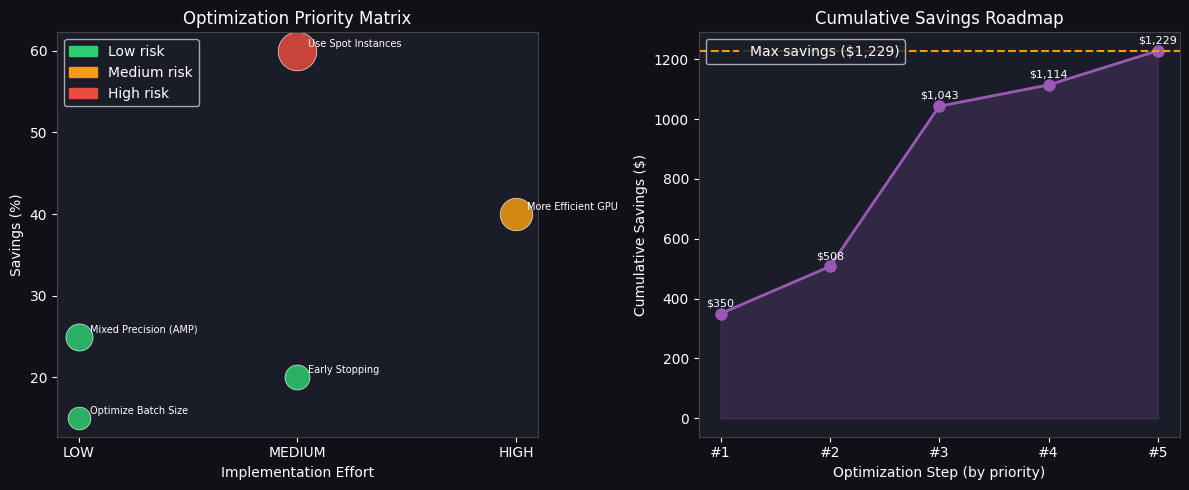

✅ Saved: optimization_roadmap.png


In [81]:
# Cell 29: Optimization Opportunity Analysis
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies by ROI.
    """
    # Base URL Cloudflare Tunnel
    BASE_URL = "https://washer-attitude-wisdom-tigers.trycloudflare.com"
    # Get base price from API
    r = requests.get( f"{BASE_URL}/", timeout=10 )
    pricing_data = r.json()

    # Build price lookup
    price_lookup = {}
    for item in pricing_data.get("pricing", []):
        price_lookup[item.get("gpu_type", "").upper()] = item["price_per_hour"]
    fallback = {"T4": 0.35, "A100": 3.50, "V100": 2.48, "P100": 1.46}

    gpu_type = current_config["gpu_type"].upper()
    price = price_lookup.get(gpu_type) or fallback.get(gpu_type, 1.0)
    current_cost = price * current_config["gpu_count"] * current_config["duration_hours"]

    # Effort & risk score (dùng để tính priority)
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_score   = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

    analyzed = []
    for s in optimization_strategies:
        savings_usd = current_cost * s["savings_pct"]
        effort = effort_score.get(s["implementation_effort"], 2)
        risk   = risk_score.get(s["risk_level"], 2)

        # Priority score: savings cao, effort thấp, risk thấp = ưu tiên cao
        priority_score = (s["savings_pct"] * 100) / (effort * risk)

        analyzed.append({
            "name": s["name"],
            "savings_pct": s["savings_pct"] * 100,
            "savings_usd": round(savings_usd, 2),
            "effort": s["implementation_effort"],
            "risk": s["risk_level"],
            "dependencies": s["dependencies"],
            "priority_score": round(priority_score, 2),
        })

    # Sắp xếp theo priority score giảm dần
    analyzed.sort(key=lambda x: x["priority_score"], reverse=True)

    # Tính cumulative savings (không cộng đơn giản vì các opt tương tác nhau)
    # Dùng công thức: remaining = remaining * (1 - savings_pct)
    remaining_cost = current_cost
    cumulative = []
    for item in analyzed:
        saved = remaining_cost * (item["savings_pct"] / 100)
        remaining_cost -= saved
        cumulative.append(round(current_cost - remaining_cost, 2))

    # Gán cumulative vào từng item
    for i, item in enumerate(analyzed):
        item["cumulative_savings_usd"] = cumulative[i]
        item["rank"] = i + 1

    # Tạo roadmap theo phase
    quick_wins   = [x for x in analyzed if x["effort"] == "LOW"   and x["risk"] == "LOW"]
    medium_term  = [x for x in analyzed if x["effort"] == "MEDIUM" or (x["effort"] == "LOW" and x["risk"] != "LOW")]
    long_term    = [x for x in analyzed if x["effort"] == "HIGH"]

    return {
        "current_cost_usd": round(current_cost, 2),
        "current_config": current_config,"strategies": analyzed,
        "max_total_savings_usd": round(current_cost - remaining_cost, 2),
        "max_savings_pct": round((current_cost - remaining_cost) / current_cost * 100, 1),
        "roadmap": {
            "phase1_quick_wins": quick_wins,
            "phase2_medium_term": medium_term,
            "phase3_long_term": long_term,
        }
    }

# Example data
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Use Spot Instances",              "savings_pct": 0.60, "implementation_effort": "MEDIUM",  "risk_level": "HIGH",   "dependencies": []},
    {"name": "Optimize Batch Size",             "savings_pct": 0.15, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Implement Early Stopping",        "savings_pct": 0.20, "implementation_effort": "MEDIUM",  "risk_level": "LOW",    "dependencies": []},
    {"name": "Switch to More Efficient GPU",    "savings_pct": 0.40, "implementation_effort": "HIGH",   "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# Gọi function
result = analyze_optimization_opportunities(current_training_config, example_strategies)

# Hiển thị thông tin hiện tại
print(f"\n⚙️  Current Config : {result['current_config']['gpu_count']}x {result['current_config']['gpu_type']} "
      f"| {result['current_config']['duration_hours']}h | {result['current_config']['precision']}")
print(f"💸 Current Cost   : ${result['current_cost_usd']:,.2f}")

# Bảng ranked strategies
print(f"\n{'Rank':<5} {'Strategy':<35} {'Save%':<7} {'Save$':<10} {'Effort':<8} {'Risk':<8} {'Cumul.$':<10} {'Score'}")
print("-" * 95)
for s in result["strategies"]:
    print(f"{s['rank']:<5} {s['name']:<35} {s['savings_pct']:<7.0f} "
          f"${s['savings_usd']:<9} {s['effort']:<8} {s['risk']:<8} "
          f"${s['cumulative_savings_usd']:<9} {s['priority_score']}")

# Tổng kết
print(f"\n✅ Max Combined Savings: ${result['max_total_savings_usd']:,.2f} ({result['max_savings_pct']}%)")

# Roadmap
print("\n" + "=" * 60)
print("🗺️  OPTIMIZATION ROADMAP")
print("=" * 60)

phases = [
    ("🟢 Phase 1 - Quick Wins (implement immediately)", result["roadmap"]["phase1_quick_wins"]),
    ("🟡 Phase 2 - Medium Term (plan next sprint)",     result["roadmap"]["phase2_medium_term"]),
    ("🔴 Phase 3 - Long Term (future planning)",        result["roadmap"]["phase3_long_term"]),
]
for phase_name, items in phases:
    print(f"\n{phase_name}")
    if items:
        for item in items:
            print(f"   • {item['name']} → Save ${item['savings_usd']:,.2f} ({item['savings_pct']:.0f}%)")
    else:
        print("   (none)")

# Save optimization_roadmap.png
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig3.patch.set_facecolor("#0f1117")
for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

import matplotlib.patches as mpatches
strategies  = result["strategies"]
effort_map  = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
risk_colors = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"}
for s in strategies:
    ex = effort_map[s["effort"]]
    ax1.scatter(ex, s["savings_pct"], s=s["savings_usd"]*0.8+100,
                color=risk_colors[s["risk"]], alpha=0.85, edgecolors="white", linewidths=0.5)
    ax1.text(ex+0.05, s["savings_pct"]+0.5,
             s["name"].replace("Switch to ","").replace("Implement ",""),
             color="white", fontsize=7)
ax1.set_title("Optimization Priority Matrix", color="white")
ax1.set_xlabel("Implementation Effort")
ax1.set_ylabel("Savings (%)")
ax1.set_xticks([1,2,3])
ax1.set_xticklabels(["LOW","MEDIUM","HIGH"])
ax1.legend(handles=[
    mpatches.Patch(color="#2ecc71", label="Low risk"),
    mpatches.Patch(color="#f39c12", label="Medium risk"),
    mpatches.Patch(color="#e74c3c", label="High risk"),
], facecolor="#1a1d27", labelcolor="white")

names  = [s["name"].replace("Switch to ","").replace("Implement ","") for s in strategies]
cumuls = [s["cumulative_savings_usd"] for s in strategies]
ax2.plot(range(1, len(cumuls)+1), cumuls, "o-", color="#9b59b6", linewidth=2, markersize=8)
ax2.fill_between(range(1, len(cumuls)+1), cumuls, alpha=0.2, color="#9b59b6")
ax2.axhline(result["max_total_savings_usd"], color="#f39c12", linestyle="--",
            label=f"Max savings (${result['max_total_savings_usd']:,.0f})")
for i, val in enumerate(cumuls):
    ax2.text(i+1, val + result["max_total_savings_usd"]*0.02,
             f"${val:,.0f}", ha="center", color="white", fontsize=8)
ax2.set_title("Cumulative Savings Roadmap", color="white")
ax2.set_xlabel("Optimization Step (by priority)")
ax2.set_ylabel("Cumulative Savings ($)")
ax2.set_xticks(range(1, len(cumuls)+1))
ax2.set_xticklabels([f"#{i+1}" for i in range(len(cumuls))])
ax2.legend(facecolor="#1a1d27", labelcolor="white")

plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print("✅ Saved: optimization_roadmap.png")

EXERCISE 8.5.4: Integrated Cost Dashboard


/tmp/ipykernel_57/2863238417.py:136: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2863238417.py:137: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


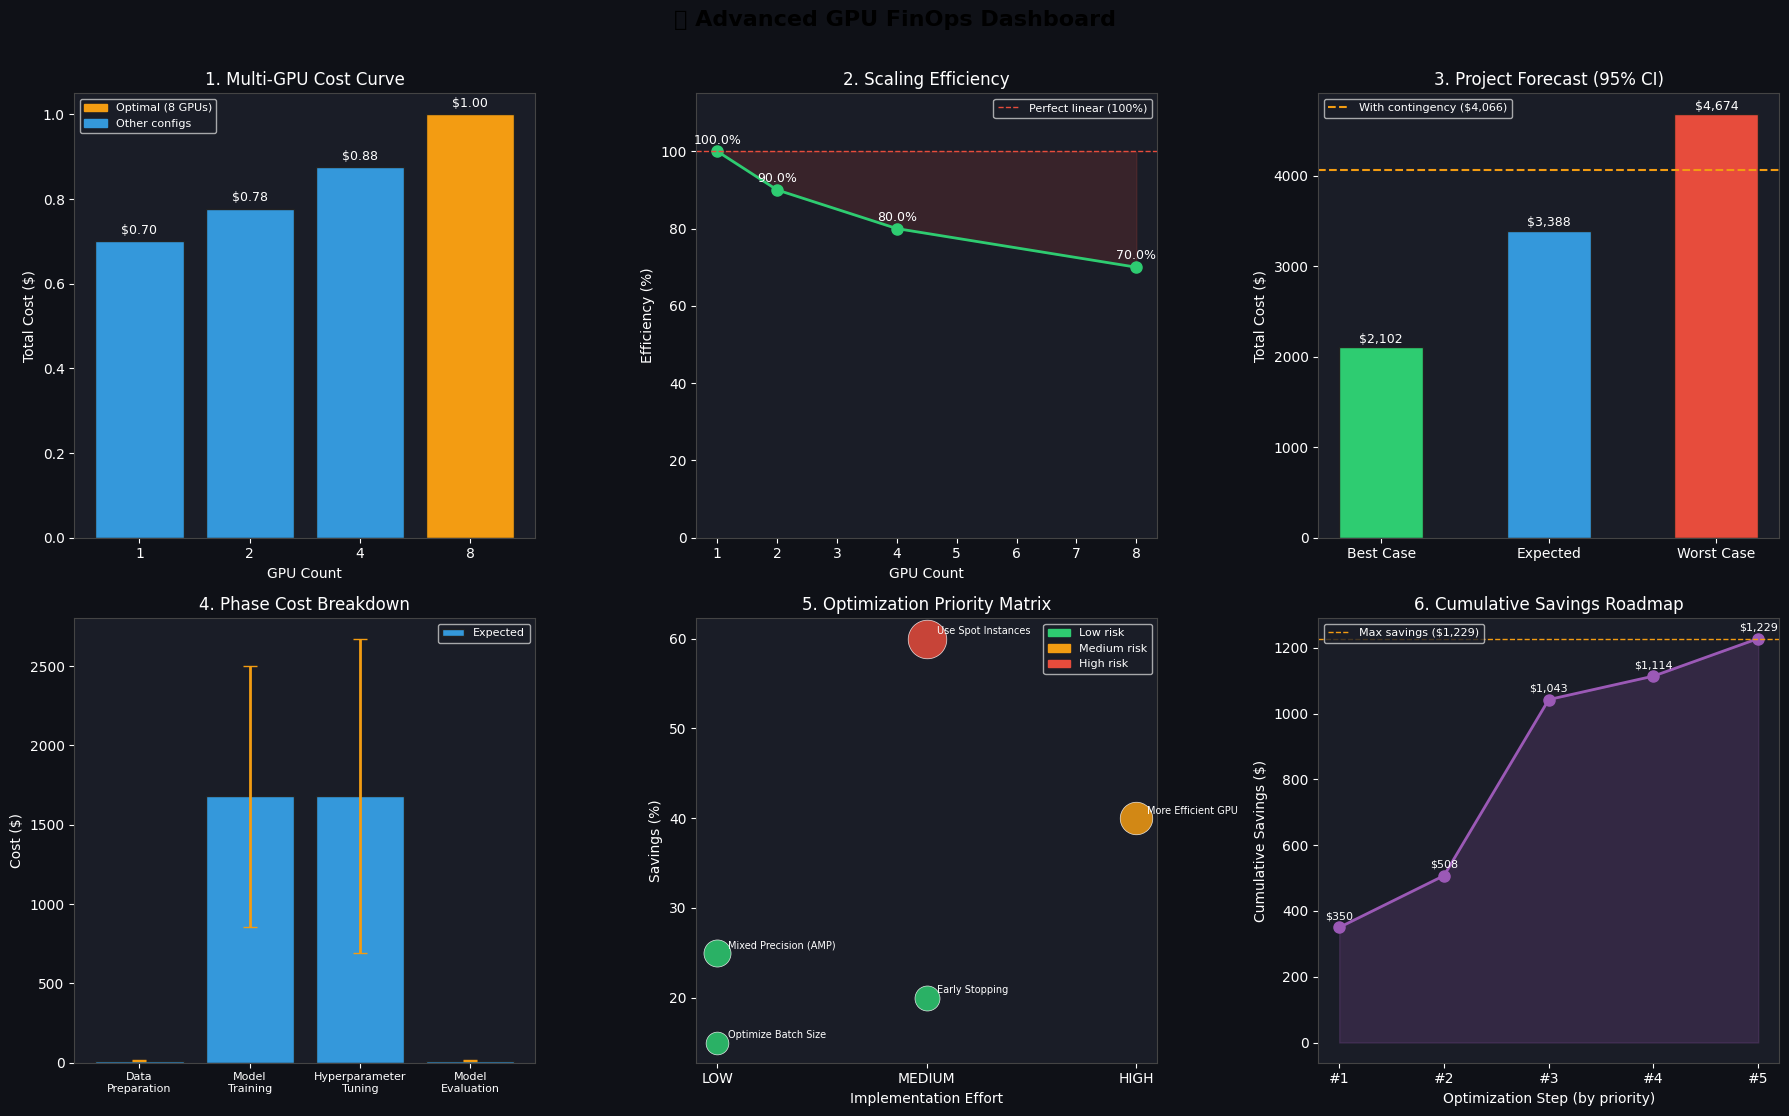


✅ Dashboard saved: advanced_finops_dashboard.png


In [82]:
# Cell 30: Integrated Cost Dashboard
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("🖥️ Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold", y=1.01)
    fig.patch.set_facecolor("#0f1117")
    for ax in axes.flatten():
        ax.set_facecolor("#1a1d27")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")

    cfgs = multi_gpu_analysis["configurations"]
    gpu_counts = [c["gpu_count"] for c in cfgs]
    costs      = [c["total_cost_usd"] for c in cfgs]
    optimal    = multi_gpu_analysis["optimal_gpu_count"]

    # ── Plot 1: Multi-GPU Cost Curve ──
    ax1 = axes[0, 0]
    colors = ["#f39c12" if g == optimal else "#3498db" for g in gpu_counts]
    bars = ax1.bar([str(g) for g in gpu_counts], costs, color=colors, edgecolor="#222")
    ax1.set_title("1. Multi-GPU Cost Curve")
    ax1.set_xlabel("GPU Count")
    ax1.set_ylabel("Total Cost ($)")
    for bar, cost in zip(bars, costs):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"${cost:.2f}", ha="center", va="bottom", color="white", fontsize=9)
    ax1.legend(handles=[
        mpatches.Patch(color="#f39c12", label=f"Optimal ({optimal} GPUs)"),
        mpatches.Patch(color="#3498db", label="Other configs"),
    ], facecolor="#1a1d27", labelcolor="white", fontsize=8)

    # ── Plot 2: Scaling Efficiency ──
    ax2 = axes[0, 1]
    efficiencies = [c["efficiency_pct"] for c in cfgs]
    ax2.plot(gpu_counts, efficiencies, "o-", color="#2ecc71", linewidth=2, markersize=8)
    ax2.axhline(100, color="#e74c3c", linestyle="--", linewidth=1, label="Perfect linear (100%)")
    ax2.fill_between(gpu_counts, efficiencies, 100, alpha=0.15, color="#e74c3c")
    ax2.set_title("2. Scaling Efficiency")
    ax2.set_xlabel("GPU Count")
    ax2.set_ylabel("Efficiency (%)")
    ax2.set_ylim(0, 115)
    for x, y in zip(gpu_counts, efficiencies):
        ax2.text(x, y + 2, f"{y}%", ha="center", color="white", fontsize=9)
    ax2.legend(facecolor="#1a1d27", labelcolor="white", fontsize=8)

    # ── Plot 3: Project Forecast with Confidence Intervals ──
    ax3 = axes[0, 2]
    ci   = project_forecast["confidence_interval"]
    cats = ["Best Case", "Expected", "Worst Case"]
    vals = [ci["best_case"], ci["expected"], ci["worst_case"]]
    bar_colors = ["#2ecc71", "#3498db", "#e74c3c"]
    b3 = ax3.bar(cats, vals, color=bar_colors, edgecolor="#222", width=0.5)
    ax3.axhline(project_forecast["total_with_contingency"], color="#f39c12",linestyle="--", linewidth=1.5, label=f"With contingency (${project_forecast['total_with_contingency']:,.0f})")
    ax3.set_title(f"3. Project Forecast ({int(project_forecast['confidence_level']*100)}% CI)")
    ax3.set_ylabel("Total Cost ($)")
    for bar, val in zip(b3, vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"${val:,.0f}", ha="center", color="white", fontsize=9)
    ax3.legend(facecolor="#1a1d27", labelcolor="white", fontsize=8)

    # ── Plot 4: Phase-by-phase Cost Breakdown ──
    ax4 = axes[1, 0]
    phases      = project_forecast["phases"]
    phase_names = [p["name"].replace(" ", "\n") for p in phases]
    phase_costs = [p["base_cost"] for p in phases]
    phase_worst = [p["worst_case"] for p in phases]
    phase_best  = [p["best_case"]  for p in phases]
    x = np.arange(len(phases))
    ax4.bar(x, phase_costs, color="#3498db", label="Expected", edgecolor="#222")
    ax4.errorbar(x, phase_costs,
                 yerr=[[c - b for c, b in zip(phase_costs, phase_best)],
                       [w - c for w, c in zip(phase_worst, phase_costs)]],
                 fmt="none", color="#f39c12", capsize=5, linewidth=2)
    ax4.set_title("4. Phase Cost Breakdown")
    ax4.set_ylabel("Cost ($)")
    ax4.set_xticks(x)
    ax4.set_xticklabels(phase_names, fontsize=8)
    ax4.legend(facecolor="#1a1d27", labelcolor="white", fontsize=8)

    # ── Plot 5: Optimization Prioritization Matrix ──
    ax5 = axes[1, 1]
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_map   = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_colors = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"}
    strategies  = optimization_recommendations["strategies"]
    for s in strategies:
        ex = effort_map[s["effort"]]
        rx = risk_map[s["risk"]]
        ax5.scatter(ex, s["savings_pct"], s=s["savings_usd"] * 0.8 + 100,
                    color=risk_colors[s["risk"]], alpha=0.85, edgecolors="white", linewidths=0.5)
        ax5.text(ex + 0.05, s["savings_pct"] + 0.5,
                 s["name"].replace("Switch to ", "").replace("Implement ", ""),
                 color="white", fontsize=7)
    ax5.set_title("5. Optimization Priority Matrix")
    ax5.set_xlabel("Implementation Effort")
    ax5.set_ylabel("Savings (%)")
    ax5.set_xticks([1, 2, 3])
    ax5.set_xticklabels(["LOW", "MEDIUM", "HIGH"])
    ax5.legend(handles=[
        mpatches.Patch(color="#2ecc71", label="Low risk"),
        mpatches.Patch(color="#f39c12", label="Medium risk"),
        mpatches.Patch(color="#e74c3c", label="High risk"),
    ], facecolor="#1a1d27", labelcolor="white", fontsize=8)

    # ── Plot 6: Cumulative Savings Roadmap ──
    ax6 = axes[1, 2]
    names  = [s["name"].replace("Switch to ", "").replace("Implement ", "") for s in strategies]
    cumuls = [s["cumulative_savings_usd"] for s in strategies]
    ax6.plot(range(1, len(cumuls)+1), cumuls, "o-", color="#9b59b6", linewidth=2, markersize=8)
    ax6.fill_between(range(1, len(cumuls)+1), cumuls, alpha=0.2, color="#9b59b6")
    ax6.axhline(optimization_recommendations["max_total_savings_usd"],
                color="#f39c12", linestyle="--", linewidth=1,
                label=f"Max savings (${optimization_recommendations['max_total_savings_usd']:,.0f})")
    for i, (val, name) in enumerate(zip(cumuls, names)):
        ax6.text(i+1, val + optimization_recommendations["max_total_savings_usd"]*0.02,
                 f"${val:,.0f}", ha="center", color="white", fontsize=8)
    ax6.set_title("6. Cumulative Savings Roadmap")
    ax6.set_xlabel("Optimization Step (by priority)")
    ax6.set_ylabel("Cumulative Savings ($)")
    ax6.set_xticks(range(1, len(cumuls)+1))
    ax6.set_xticklabels([f"#{i+1}" for i in range(len(cumuls))])
    ax6.legend(facecolor="#1a1d27", labelcolor="white", fontsize=8)

    plt.tight_layout()
    plt.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("\n✅ Dashboard saved: advanced_finops_dashboard.png")
    return fig

# Gọi với kết quả từ các cell trước
fig = create_advanced_finops_dashboard(analysis, forecast, result)

In [83]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
display_student_header()
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project  : {challenge_scenario['project']}")
print(f"   Baseline : {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget   : ${challenge_scenario['requirements']['budget']:,}")
print(f"   Deadline : {challenge_scenario['constraints']['deadline']}")

BASE_URL = "https://washer-attitude-wisdom-tigers.trycloudflare.com"
# Get base price from API
r = requests.get( f"{BASE_URL}/", timeout=10 )
pricing_data = r.json()
price_lookup = {}
for item in pricing_data.get("pricing", []):
    price_lookup[item.get("gpu_type","").upper()] = item["price_per_hour"]
fallback = {"T4": 0.35, "A100": 3.50, "V100": 2.48, "P100": 1.46}

req = challenge_scenario["requirements"]
price = price_lookup.get(req["gpu_type"].upper()) or fallback.get(req["gpu_type"].upper(), 1.0)
baseline_cost = price * req["gpu_count"] * req["training_duration"]

print(f"\n{'='*60}")
print(f"STEP 1: Baseline Cost")
print(f"{'='*60}")
print(f"   {req['gpu_count']}x {req['gpu_type']} × ${price}/hr × {req['training_duration']}h = ${baseline_cost:,.2f}")
budget = req["budget"]
over_budget = baseline_cost - budget
print(f"   ⚠️  Over budget by: ${over_budget:,.2f} ({over_budget/budget*100:.1f}%)")

# ── Step 2: Multi-GPU Analysis ──
print(f"\n{'='*60}")
print(f"STEP 2: Optimal GPU Count Analysis")
print(f"{'='*60}")
gpu_analysis = analyze_multi_gpu_cost(req["training_duration"], req["gpu_type"], [1,2,4,8])
print(f"\n{'GPUs':<6} {'Time(h)':<10} {'Cost($)':<12} {'Efficiency':<12} {'Cost/Perf'}")
print("-" * 55)
for cfg in gpu_analysis["configurations"]:
    marker = " ⭐ OPTIMAL" if cfg["gpu_count"] == gpu_analysis["optimal_gpu_count"] else ""
    print(f"{cfg['gpu_count']:<6} {cfg['time_hours']:<10} ${cfg['total_cost_usd']:<11} {cfg['efficiency_pct']:<12}% ${cfg['cost_per_perf']}{marker}")
optimal_cfg = gpu_analysis["optimal_config"]
print(f"\n   → Optimal: {gpu_analysis['optimal_gpu_count']} GPUs | Cost: ${optimal_cfg['total_cost_usd']:,.2f} | Time: {optimal_cfg['time_hours']}h")

# ── Step 3: Chọn Optimization Strategies phù hợp constraint ──
print(f"\n{'='*60}")
print(f"STEP 3: Select Optimization Strategies")
print(f"  (max_preemption_risk=MEDIUM → exclude HIGH risk spot instances)")
print(f"{'='*60}")

# Spot instance bị loại vì risk=HIGH > constraint MEDIUM
selected_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Optimize Batch Size",             "savings_pct": 0.15, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Implement Early Stopping",        "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW",    "dependencies": []},
    {"name": "Switch to More Efficient GPU",    "savings_pct": 0.40, "implementation_effort": "HIGH",   "risk_level": "MEDIUM", "dependencies": []},
]

opt_config = {
    "gpu_type": req["gpu_type"],
    "gpu_count": gpu_analysis["optimal_gpu_count"],
    "duration_hours": optimal_cfg["time_hours"],
    "precision": req["precision"],
    "instance_type": req["instance_type"],
}
opt_result = analyze_optimization_opportunities(opt_config, selected_strategies)

print(f"\n{'#':<4} {'Strategy':<35} {'Save%':<7} {'Save$':<10} {'Effort':<8} {'Risk'}")
print("-" * 70)
for s in opt_result["strategies"]:
    print(f"{s['rank']:<4} {s['name']:<35} {s['savings_pct']:<7.0f}% ${s['savings_usd']:<9} {s['effort']:<8} {s['risk']}")

# ── Step 4: Final Cost Calculation ──
print(f"\n{'='*60}")
print(f"STEP 4: Cumulative Savings & Final Cost")
print(f"{'='*60}")
optimized_base = opt_result["current_cost_usd"]
total_saved    = opt_result["max_total_savings_usd"]
final_cost     = optimized_base - total_saved

print(f"   After GPU optimization  : ${optimized_base:,.2f}")
print(f"   After all strategies    : -${total_saved:,.2f} ({opt_result['max_savings_pct']}%)")
print(f"   Final Estimated Cost    : ${final_cost:,.2f}")

# ── Step 5: Forecast với uncertainty ──
print(f"\n{'='*60}")
print(f"STEP 5: Cost Forecast with Confidence Interval")
print(f"{'='*60}")
forecast_phases = [
    {"name": "LLM Fine-tuning", "gpu_type": req["gpu_type"],
     "gpu_count": gpu_analysis["optimal_gpu_count"],
     "duration_hours": optimal_cfg["time_hours"],
     "uncertainty_pct": 0.20},
]
forecast_result = forecast_project_cost(forecast_phases, contingency_pct=15)
ci = forecast_result["confidence_interval"]
print(f"   🟢 Best Case  : ${ci['best_case']:,.2f}")
print(f"   🟡 Expected   : ${ci['expected']:,.2f}")
print(f"   🔴 Worst Case : ${ci['worst_case']:,.2f}")
print(f"   📦 With contingency (15%): ${forecast_result['total_with_contingency']:,.2f}")

# ── Step 6: Verify vs Budget & Constraints ──
print(f"\n{'='*60}")
print(f"STEP 6: Verify Budget & Constraints")
print(f"{'='*60}")
meets_budget   = forecast_result["total_with_contingency"] <= budget
meets_deadline = optimal_cfg["time_hours"] <= 14 * 24  # 2 weeks = 336h
meets_risk     = all(s["risk"] in ["LOW","MEDIUM"] for s in opt_result["strategies"])

print(f"   💰 Budget  (≤ ${budget:,})   : ${forecast_result['total_with_contingency']:,.2f} → {'✅ PASS' if meets_budget else '❌ FAIL'}")
print(f"   ⏱️  Deadline (≤ 336h)        : {optimal_cfg['time_hours']}h → {'✅ PASS' if meets_deadline else '❌ FAIL'}")
print(f"   ⚠️  Risk (≤ MEDIUM)          : All strategies ≤ MEDIUM → {'✅ PASS' if meets_risk else '❌ FAIL'}")

# ── Step 7: Strategy Summary ──
print(f"\n{'='*60}")
print(f"STEP 7: FINAL OPTIMIZATION STRATEGY SUMMARY")
print(f"{'='*60}")
print(f"""
   PROJECT  : {challenge_scenario['project']}

   BASELINE → OPTIMIZED
   ├─ GPUs     : {req['gpu_count']}x {req['gpu_type']} → {gpu_analysis['optimal_gpu_count']}x {req['gpu_type']}
   ├─ Precision: FP32 → Mixed (AMP)
   ├─ Stopping : Full run → Early stopping enabled
   ├─ Batch    : Default → Optimized batch size
   └─ Cost     : ${baseline_cost:,.2f} → ${forecast_result['total_with_contingency']:,.2f}

   SAVINGS   : ${baseline_cost - forecast_result['total_with_contingency']:,.2f} ({(baseline_cost - forecast_result['total_with_contingency'])/baseline_cost*100:.1f}% reduction)
   BUDGET    : $5,000 → {'✅ Within budget' if meets_budget else '❌ Exceeds budget'}

   ROADMAP:
   🟢 Week 1: Mixed Precision + Batch Size (quick wins, LOW effort)
   🟡 Week 2: Early Stopping (MEDIUM effort, LOW risk)
   🔴 Future: GPU type switch when ready (HIGH effort, MEDIUM risk)
""")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project  : Large Language Model Fine-tuning
   Baseline : 8x A100 for 200h
   Budget   : $5,000
   Deadline : 2 weeks

STEP 1: Baseline Cost
   8x A100 × $3.5/hr × 200h = $5,600.00
   ⚠️  Over budget by: $600.00 (12.0%)

STEP 2: Optimal GPU Count Analysis

GPUs   Time(h)    Cost($)      Efficiency   Cost/Perf
-------------------------------------------------------
1      200.0      $70.0        100.0       % $70.0
2      111.11     $77.7778     90.0        % $43.2099
4      62.5       $87.5        80.0        % $27.3438
8      35.71      $100.0       70.0        % $17.8571 ⭐ OPTIMAL

   → Optimal: 8 GPUs | Cost: $100.00 | Time: 35.71h

STEP 3: Select Optimization Strategies
  (max_preemption_risk=MEDIUM → exclude HIGH risk spot instances)

#    Strategy                            Save%   Save$      Effort   Risk
----------------------------------------------------------------------
1    Switch to Mixed

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway